In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGBoost
import xgboost as xgb

In [2]:
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame # Contains features and target

print("Dataset Info:")
df.info()

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

# Separate features (X) and target (y)
X = california_housing.data
y = california_housing.target

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

First 5 rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059  


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


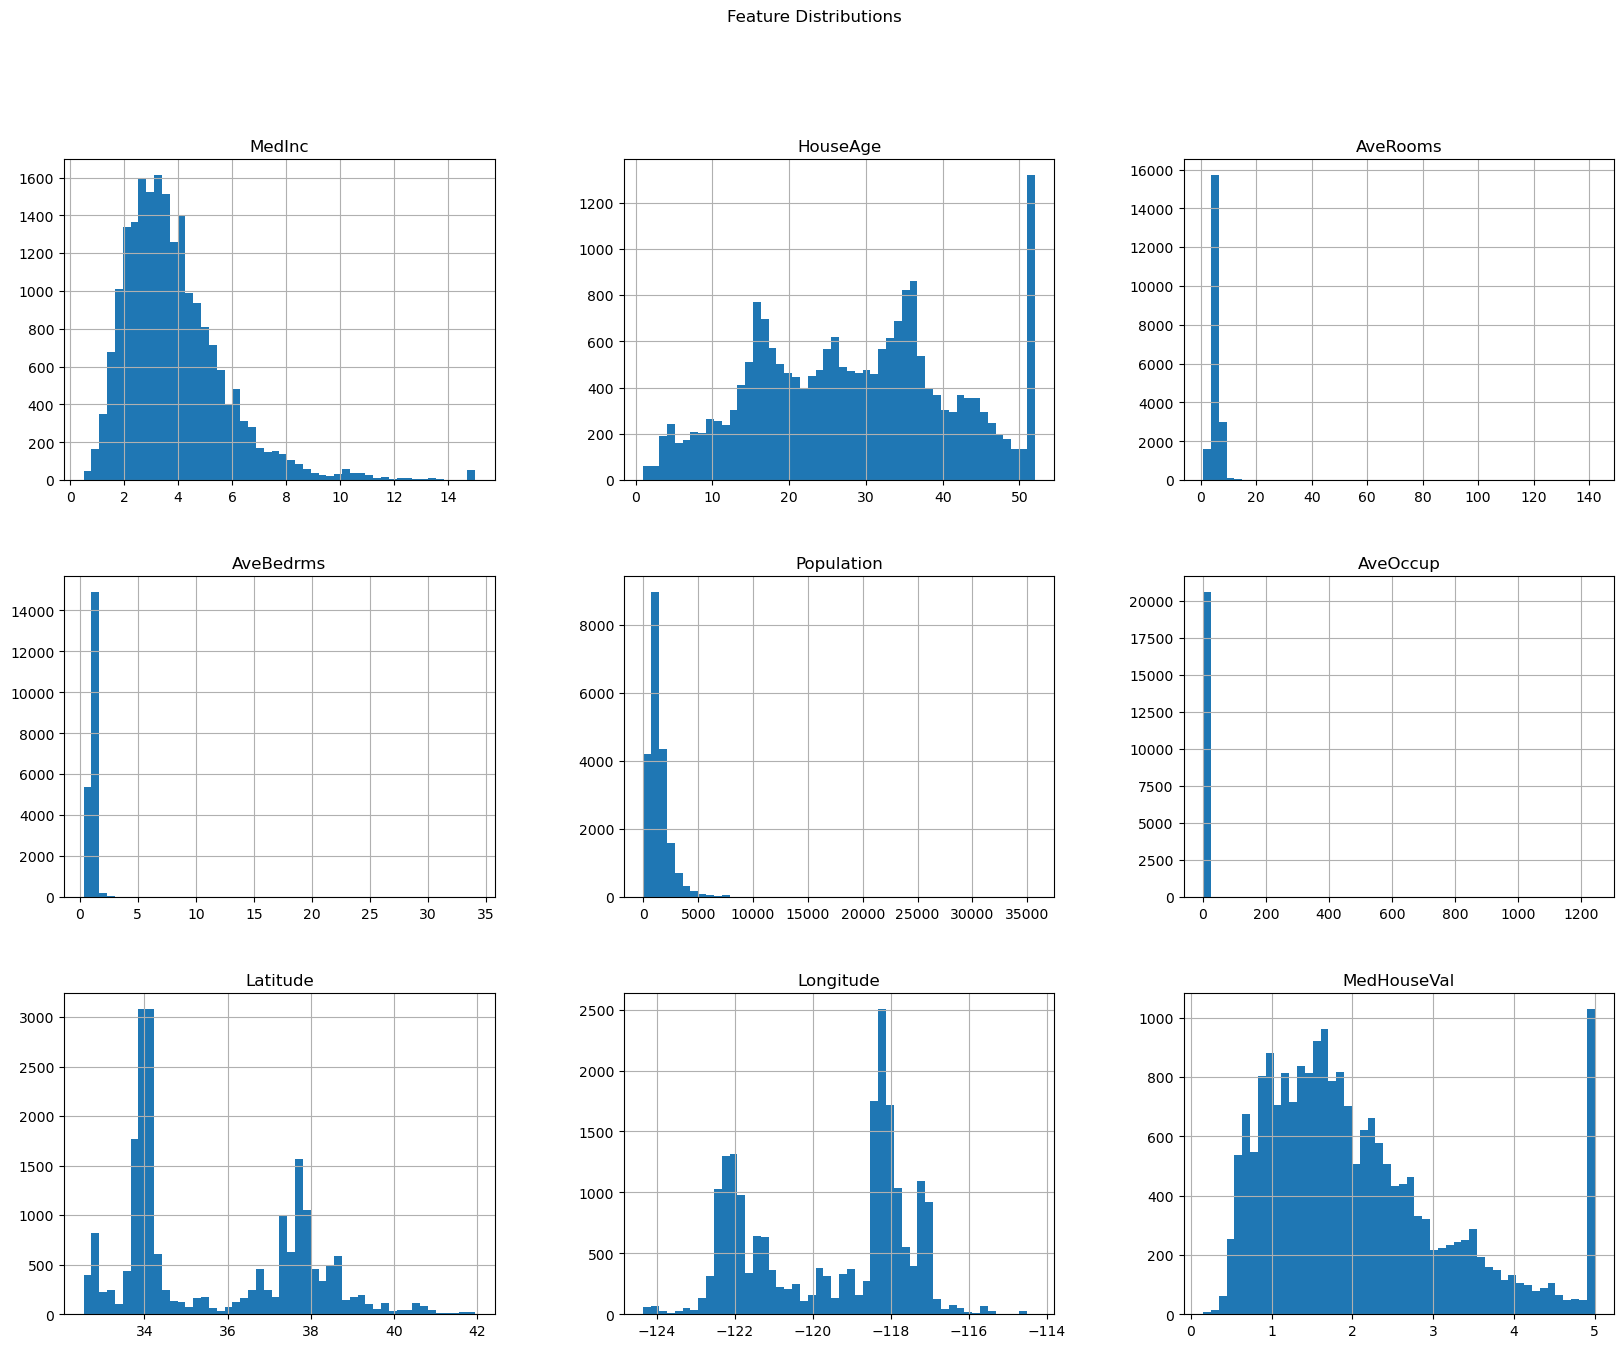

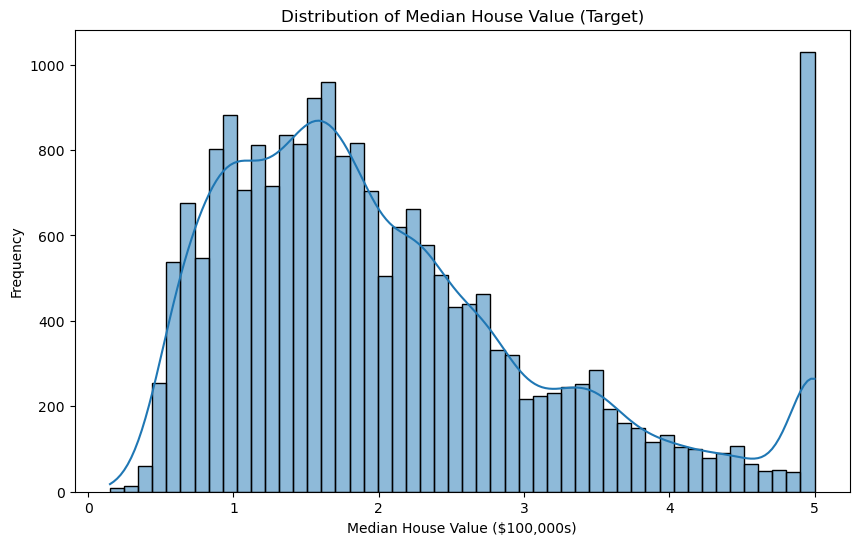

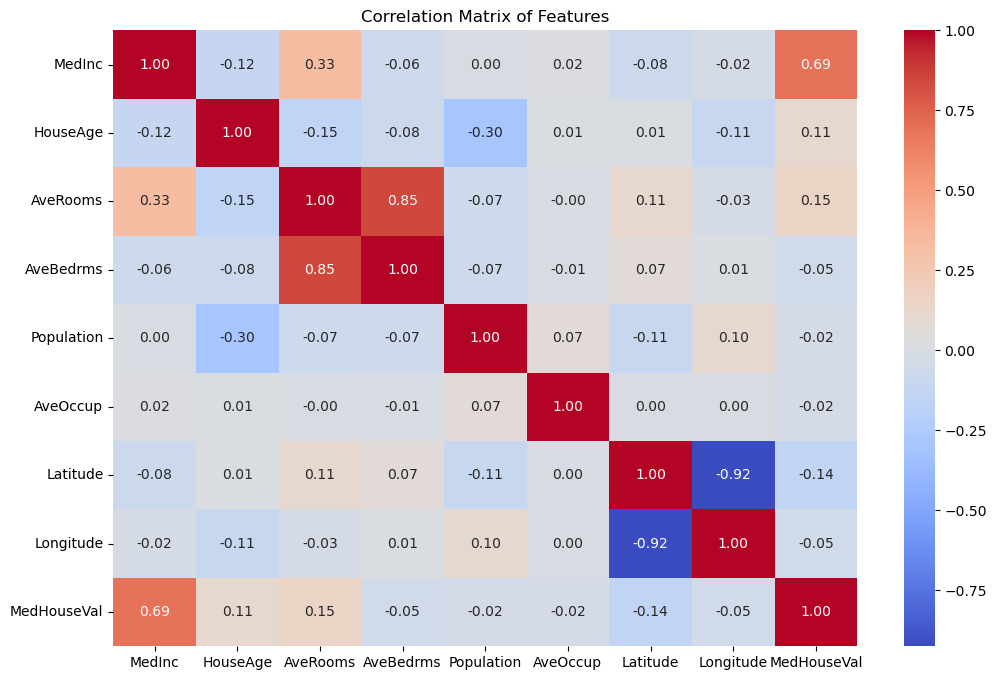

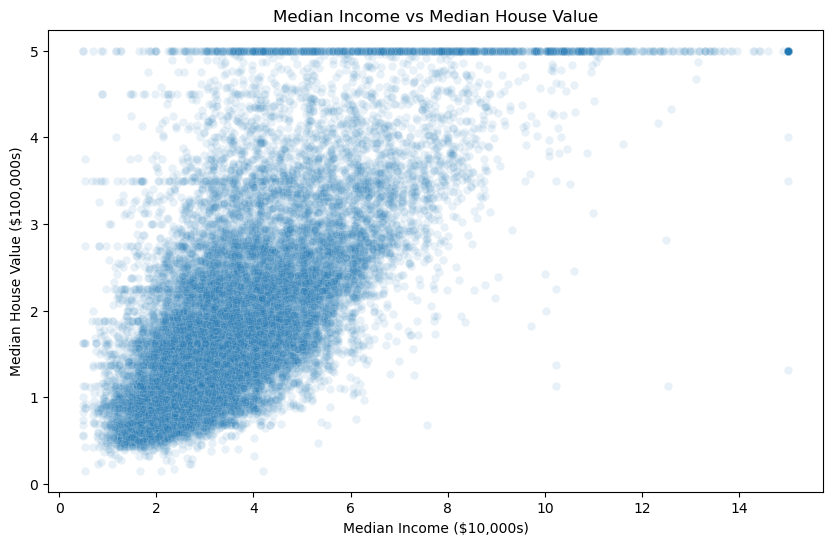

In [3]:
# Check for missing values (this dataset is clean, but it's good practice)
print("\nMissing values per column:")
print(df.isnull().sum())

df.hist(bins=50, figsize=(20,15))
plt.suptitle("Feature Distributions")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], kde=True, bins=50)
plt.title('Distribution of Median House Value (Target)')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.1)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)


Training set shape: X=(16512, 8), y=(16512,)
Testing set shape: X=(4128, 8), y=(4128,)


In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

ridge_reg = Ridge(alpha=1.0, random_state=12) 
ridge_reg.fit(X_train_scaled, y_train)

lasso_reg = Lasso(alpha=0.1, random_state=12)
lasso_reg.fit(X_train_scaled, y_train)

tree_reg = DecisionTreeRegressor(random_state=12)
tree_reg.fit(X_train_scaled, y_train) 

forest_reg = RandomForestRegressor(n_estimators=100, random_state=12, n_jobs=-1) 
forest_reg.fit(X_train_scaled, y_train)

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=12, n_jobs=-1)
xgb_reg.fit(X_train_scaled, y_train)

print("\nModels trained successfully!")


Models trained successfully!


In [6]:
models = {
    "Linear Regression": lin_reg,
    "Ridge Regression": ridge_reg,
    "Lasso Regression": lasso_reg,
    "Decision Tree": tree_reg,
    "Random Forest": forest_reg,
    "XGBoost": xgb_reg
}

results = {}

print("\n--- Evaluation Results ---")

for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

results_df = pd.DataFrame(results).T
print("\n--- Comparison Table ---")
print(results_df.round(4))


--- Evaluation Results ---

Linear Regression:
  MAE:  0.5318
  MSE:  0.5270
  RMSE: 0.7259
  R²:   0.6157

Ridge Regression:
  MAE:  0.5318
  MSE:  0.5270
  RMSE: 0.7259
  R²:   0.6157

Lasso Regression:
  MAE:  0.6179
  MSE:  0.6755
  RMSE: 0.8219
  R²:   0.5074

Decision Tree:
  MAE:  0.4408
  MSE:  0.4739
  RMSE: 0.6884
  R²:   0.6544

Random Forest:
  MAE:  0.3245
  MSE:  0.2510
  RMSE: 0.5010
  R²:   0.8169

XGBoost:
  MAE:  0.3033
  MSE:  0.2171
  RMSE: 0.4659
  R²:   0.8417

--- Comparison Table ---
                      MAE     MSE    RMSE      R2
Linear Regression  0.5318  0.5270  0.7259  0.6157
Ridge Regression   0.5318  0.5270  0.7259  0.6157
Lasso Regression   0.6179  0.6755  0.8219  0.5074
Decision Tree      0.4408  0.4739  0.6884  0.6544
Random Forest      0.3245  0.2510  0.5010  0.8169
XGBoost            0.3033  0.2171  0.4659  0.8417


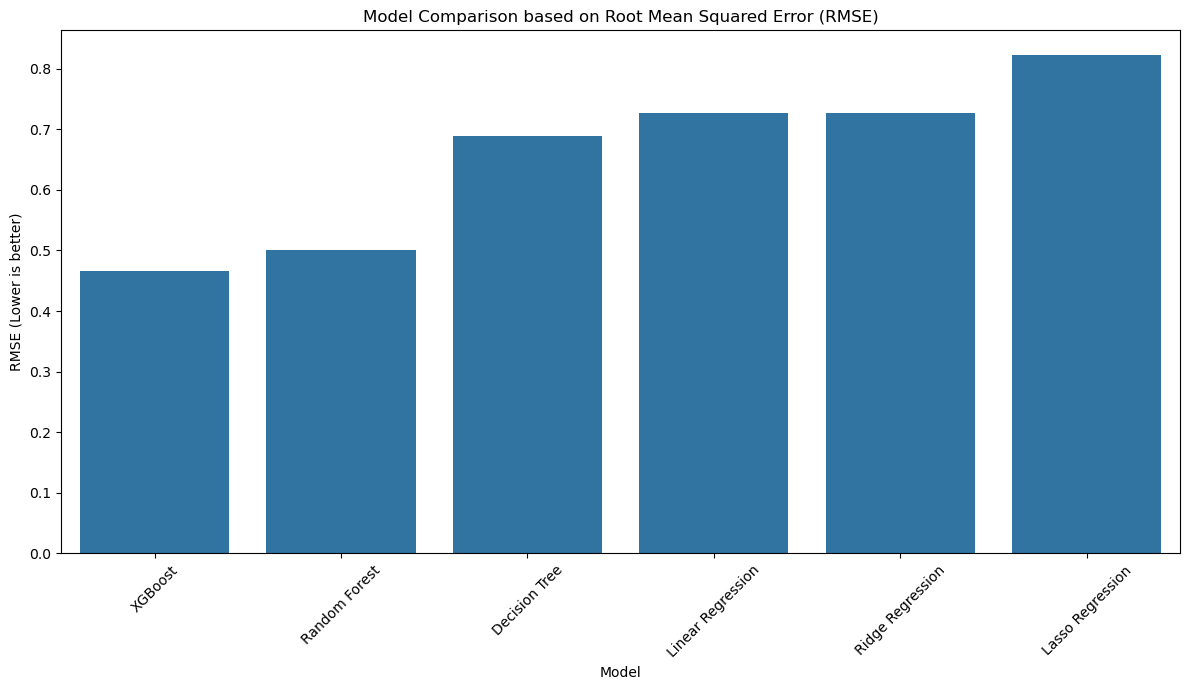

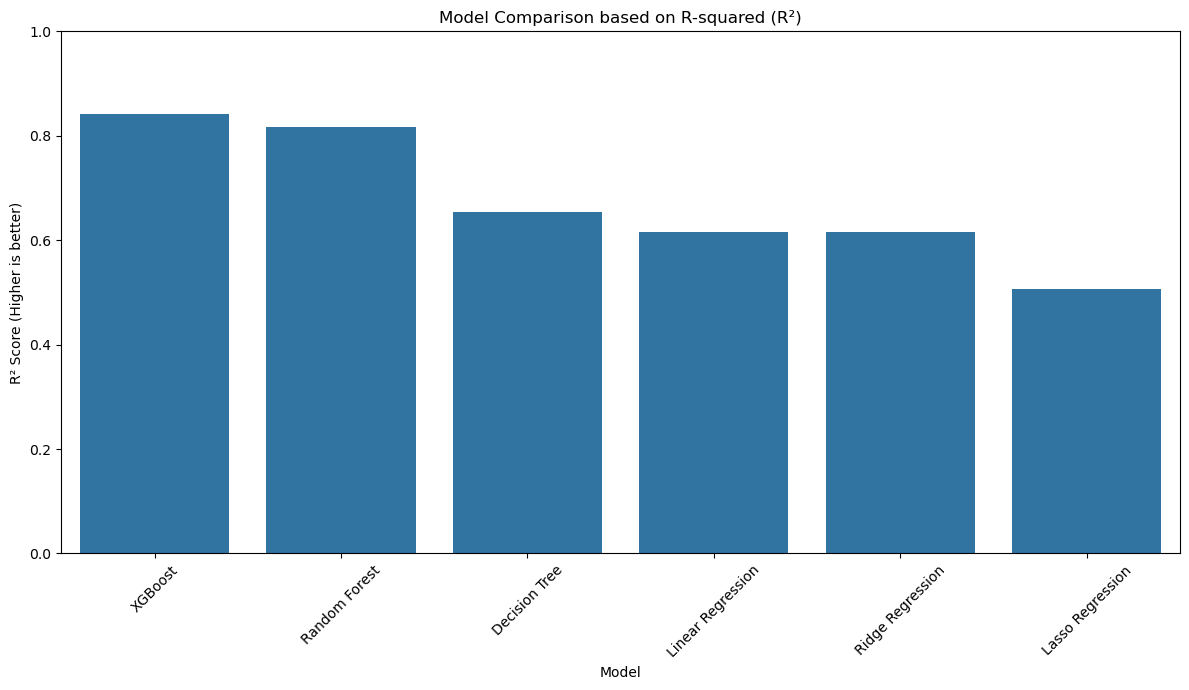

In [7]:
# 7. Visualize Comparison (Example: RMSE)
plt.figure(figsize=(12, 7))
results_df_sorted = results_df.sort_values(by='RMSE', ascending=True) # Lower RMSE is better
sns.barplot(x=results_df_sorted.index, y=results_df_sorted['RMSE'])
plt.title('Model Comparison based on Root Mean Squared Error (RMSE)')
plt.xlabel('Model')
plt.ylabel('RMSE (Lower is better)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize Comparison (Example: R-squared)
plt.figure(figsize=(12, 7))
results_df_sorted_r2 = results_df.sort_values(by='R2', ascending=False) # Higher R2 is better
sns.barplot(x=results_df_sorted_r2.index, y=results_df_sorted_r2['R2'])
plt.title('Model Comparison based on R-squared (R²)')
plt.xlabel('Model')
plt.ylabel('R² Score (Higher is better)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()